# Deterministic scenario analysis

This quick analysis evaluates sector-specific deterministic scenarios around the current representative base case:

1. electricity: low / medium / high full-load-hour scenarios;
2. electricity: low / medium / high lifetime scenarios;
3. cement: low / medium / high CO2-price scenarios;
4. cement: low / medium / high discount-rate scenarios.

The notebook uses deterministic base inputs from the reusable sensitivity helpers. It does not run Monte Carlo simulations for the scenario cases. Nothing is written to `src/`, `data/`, `results/`, or `figures/`.


In [1]:
from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cement.cement_npv_summary_figures import CEMENT_TECHNOLOGY_LABELS
from electricity.electricity_npv_summary_figures import ELECTRICITY_TECHNOLOGY_LABELS
from general_parameters import CARBON_PRICE_EUR_PER_T, INTEREST_RATE
from sensitivity_analysis import (
    METRIC_SPECIFIC,
    METRIC_TOTAL,
    base_inputs,
    calculate_metric_value,
)


## Settings

The medium cases are the current deterministic assumptions. Electricity low and high scenarios are editable multipliers around each technology's own deterministic full-load hours and lifetime. Cement CO2-price and discount-rate scenarios use explicit editable absolute values.


In [2]:
CURRENT_CO2_PRICE = CARBON_PRICE_EUR_PER_T.value
CURRENT_DISCOUNT_RATE = INTEREST_RATE.value

ELECTRICITY_FLH_MULTIPLIERS = {
    "Low": 0.80,
    "Medium": 1.00,
    "High": 1.20,
}
ELECTRICITY_LIFETIME_MULTIPLIERS = {
    "Low": 0.80,
    "Medium": 1.00,
    "High": 1.20,
}
CEMENT_CO2_PRICE_SCENARIOS = {
    "Low": 40.0,
    "Medium": CURRENT_CO2_PRICE,
    "High": 120.0,
}
CEMENT_DISCOUNT_RATE_SCENARIOS = {
    "Low": 0.04,
    "Medium": CURRENT_DISCOUNT_RATE,
    "High": 0.12,
}

# Choose the NPV metric used in the scenario figures and summary tables.
# METRIC_SPECIFIC shows EUR/MWh for electricity and EUR/t for cement;
# METRIC_TOTAL shows total project NPV in million EUR.
NPV_METRIC = METRIC_SPECIFIC  # METRIC_SPECIFIC or METRIC_TOTAL

if NPV_METRIC not in (METRIC_TOTAL, METRIC_SPECIFIC):
    raise ValueError("NPV_METRIC must be METRIC_TOTAL or METRIC_SPECIFIC.")

pd.options.display.float_format = "{:,.3f}".format

scenario_settings = pd.DataFrame(
    [
        {
            "sector": "Electricity",
            "scenario_variable": "Full-load hours",
            "low": "80% of deterministic base",
            "medium": "deterministic base",
            "high": "120% of deterministic base",
        },
        {
            "sector": "Electricity",
            "scenario_variable": "Lifetime",
            "low": "80% of deterministic base",
            "medium": "deterministic base",
            "high": "120% of deterministic base",
        },
        {
            "sector": "Cement",
            "scenario_variable": "CO2 price",
            "low": CEMENT_CO2_PRICE_SCENARIOS["Low"],
            "medium": CEMENT_CO2_PRICE_SCENARIOS["Medium"],
            "high": CEMENT_CO2_PRICE_SCENARIOS["High"],
        },
        {
            "sector": "Cement",
            "scenario_variable": "Discount rate",
            "low": CEMENT_DISCOUNT_RATE_SCENARIOS["Low"],
            "medium": CEMENT_DISCOUNT_RATE_SCENARIOS["Medium"],
            "high": CEMENT_DISCOUNT_RATE_SCENARIOS["High"],
        },
    ]
)
print(f"Selected NPV metric: {NPV_METRIC}")
display(scenario_settings)


Selected NPV metric: specific


,sector,scenario_variable,low,medium,high
0,Electricity,Full-load hours,80% of deterministic base,deterministic base,120% of deterministic base
1,Electricity,Lifetime,80% of deterministic base,deterministic base,120% of deterministic base
2,Cement,CO2 price,40.000,80.000,120.000
3,Cement,Discount rate,0.040,0.080,0.120


## Load deterministic base cases

Each scenario starts from the representative deterministic inputs used by the sensitivity dashboard. No sampled Monte Carlo draws are created.


In [3]:
ELECTRICITY_TECHNOLOGIES = tuple(ELECTRICITY_TECHNOLOGY_LABELS)
CEMENT_TECHNOLOGIES = tuple(CEMENT_TECHNOLOGY_LABELS)

electricity_base_inputs = {
    technology: base_inputs("electricity", technology)
    for technology in ELECTRICITY_TECHNOLOGIES
}
cement_base_inputs = {
    technology: base_inputs("cement", technology)
    for technology in CEMENT_TECHNOLOGIES
}

print(f"Electricity deterministic technologies: {len(electricity_base_inputs)}")
print(f"Cement deterministic technologies: {len(cement_base_inputs)}")


Electricity deterministic technologies: 9
Cement deterministic technologies: 9


## Scenario helpers

The helper replaces one deterministic input at a time and recalculates the selected NPV metric. Electricity full-load-hour changes also resize capacity through the shared deterministic NPV helper.


In [4]:
SCENARIO_ORDER = ["Low", "Medium", "High"]
SCENARIO_COLORS = {"Low": "#6BAED6", "Medium": "#4472C4", "High": "#D95F5F"}


def metric_unit(sector_key):
    if NPV_METRIC == METRIC_TOTAL:
        return "million EUR"
    return "EUR/MWh" if sector_key == "electricity" else "EUR/t"


def build_deterministic_scenario_summary(
    sector_key,
    base_by_technology,
    labels,
    scenario_variable,
    attribute,
    scenario_values,
    values_are_multipliers=False,
):
    rows = []
    for technology, inputs in base_by_technology.items():
        base_metric = calculate_metric_value(sector_key, inputs, NPV_METRIC)
        base_value = getattr(inputs, attribute)
        for scenario, scenario_value in scenario_values.items():
            applied_value = (
                base_value * scenario_value
                if values_are_multipliers
                else scenario_value
            )
            scenario_inputs = replace(inputs, **{attribute: applied_value})
            npv = calculate_metric_value(sector_key, scenario_inputs, NPV_METRIC)
            rows.append(
                {
                    "sector": "Electricity" if sector_key == "electricity" else "Cement",
                    "technology": technology,
                    "label": labels.get(technology, technology),
                    "scenario_variable": scenario_variable,
                    "scenario": scenario,
                    "scenario_setting": scenario_value,
                    "base_value": base_value,
                    "applied_value": applied_value,
                    "npv": npv,
                    "delta_from_medium": npv - base_metric,
                }
            )
    return pd.DataFrame(rows)


def plot_scenario_variables(summary, figure_title, sector_key):
    variables = summary["scenario_variable"].drop_duplicates().tolist()
    max_abs_npv = float(summary["npv"].abs().max())
    x_margin = max(1.0, 0.08 * max_abs_npv)
    x_limit = max_abs_npv + x_margin
    fig, axes = plt.subplots(1, len(variables), figsize=(8.5 * len(variables), 7.5), dpi=150)
    if len(variables) == 1:
        axes = [axes]

    for ax, variable in zip(axes, variables):
        variable_data = summary[summary["scenario_variable"] == variable]
        medium_order = (
            variable_data[variable_data["scenario"] == "Medium"]
            .sort_values("npv", ascending=True)["label"]
            .tolist()
        )
        y = np.arange(len(medium_order))
        bar_height = 0.22

        for offset, scenario in zip([-bar_height, 0.0, bar_height], SCENARIO_ORDER):
            values = (
                variable_data[variable_data["scenario"] == scenario]
                .set_index("label")
                .loc[medium_order, "npv"]
            )
            ax.barh(
                y + offset,
                values,
                height=bar_height * 0.88,
                color=SCENARIO_COLORS[scenario],
                label=scenario,
            )

        ax.set_yticks(y)
        ax.set_yticklabels(medium_order, fontsize=9)
        ax.tick_params(axis="y", left=False, length=0)
        ax.axvline(0, color="#777777", linewidth=0.9)
        ax.grid(axis="x", color="#e6e6e6", linewidth=0.8)
        ax.set_axisbelow(True)
        ax.set_title(variable, fontsize=13)
        ax.set_xlabel(f"Deterministic NPV ({metric_unit(sector_key)})")
        ax.set_xlim(-x_limit, x_limit)
        for spine in ax.spines.values():
            spine.set_visible(False)

    handles, legend_labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        legend_labels,
        title="Scenario",
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.96),
        ncol=3,
    )
    fig.suptitle(figure_title, fontsize=15, y=1.01)
    fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.90))
    return fig


## Electricity scenarios: full-load hours and lifetime

Full-load hours and lifetime vary around each technology's own deterministic base value. All other electricity inputs remain fixed at their deterministic base values.


,sector,technology,label,scenario_variable,scenario,scenario_setting,base_value,applied_value,npv,delta_from_medium
0,Electricity,hard_coal,Hard coal,Full-load hours,Low,0.800,"4,100.000","3,280.000",-28.886,-4.912
1,Electricity,hard_coal,Hard coal,Full-load hours,Medium,1.000,"4,100.000","4,100.000",-23.974,0.000
2,Electricity,hard_coal,Hard coal,Full-load hours,High,1.200,"4,100.000","4,920.000",-20.700,3.274
3,Electricity,hard_coal_ccs,Hard coal + CCS,Full-load hours,Low,0.800,"4,100.000","3,280.000",-35.715,-10.165
4,Electricity,hard_coal_ccs,Hard coal + CCS,Full-load hours,Medium,1.000,"4,100.000","4,100.000",-25.549,0.000
5,Electricity,hard_coal_ccs,Hard coal + CCS,Full-load hours,High,1.200,"4,100.000","4,920.000",-18.772,6.777
6,Electricity,ccgt,CCGT,Full-load hours,Low,0.800,"4,650.000","3,720.000",-13.048,-2.375
7,Electricity,ccgt,CCGT,Full-load hours,Medium,1.000,"4,650.000","4,650.000",-10.673,0.000
8,Electricity,ccgt,CCGT,Full-load hours,High,1.200,"4,650.000","5,580.000",-9.090,1.583
9,Electricity,ccgt_ccs,CCGT + CCS,Full-load hours,Low,0.800,"4,650.000","3,720.000",-18.568,-4.471


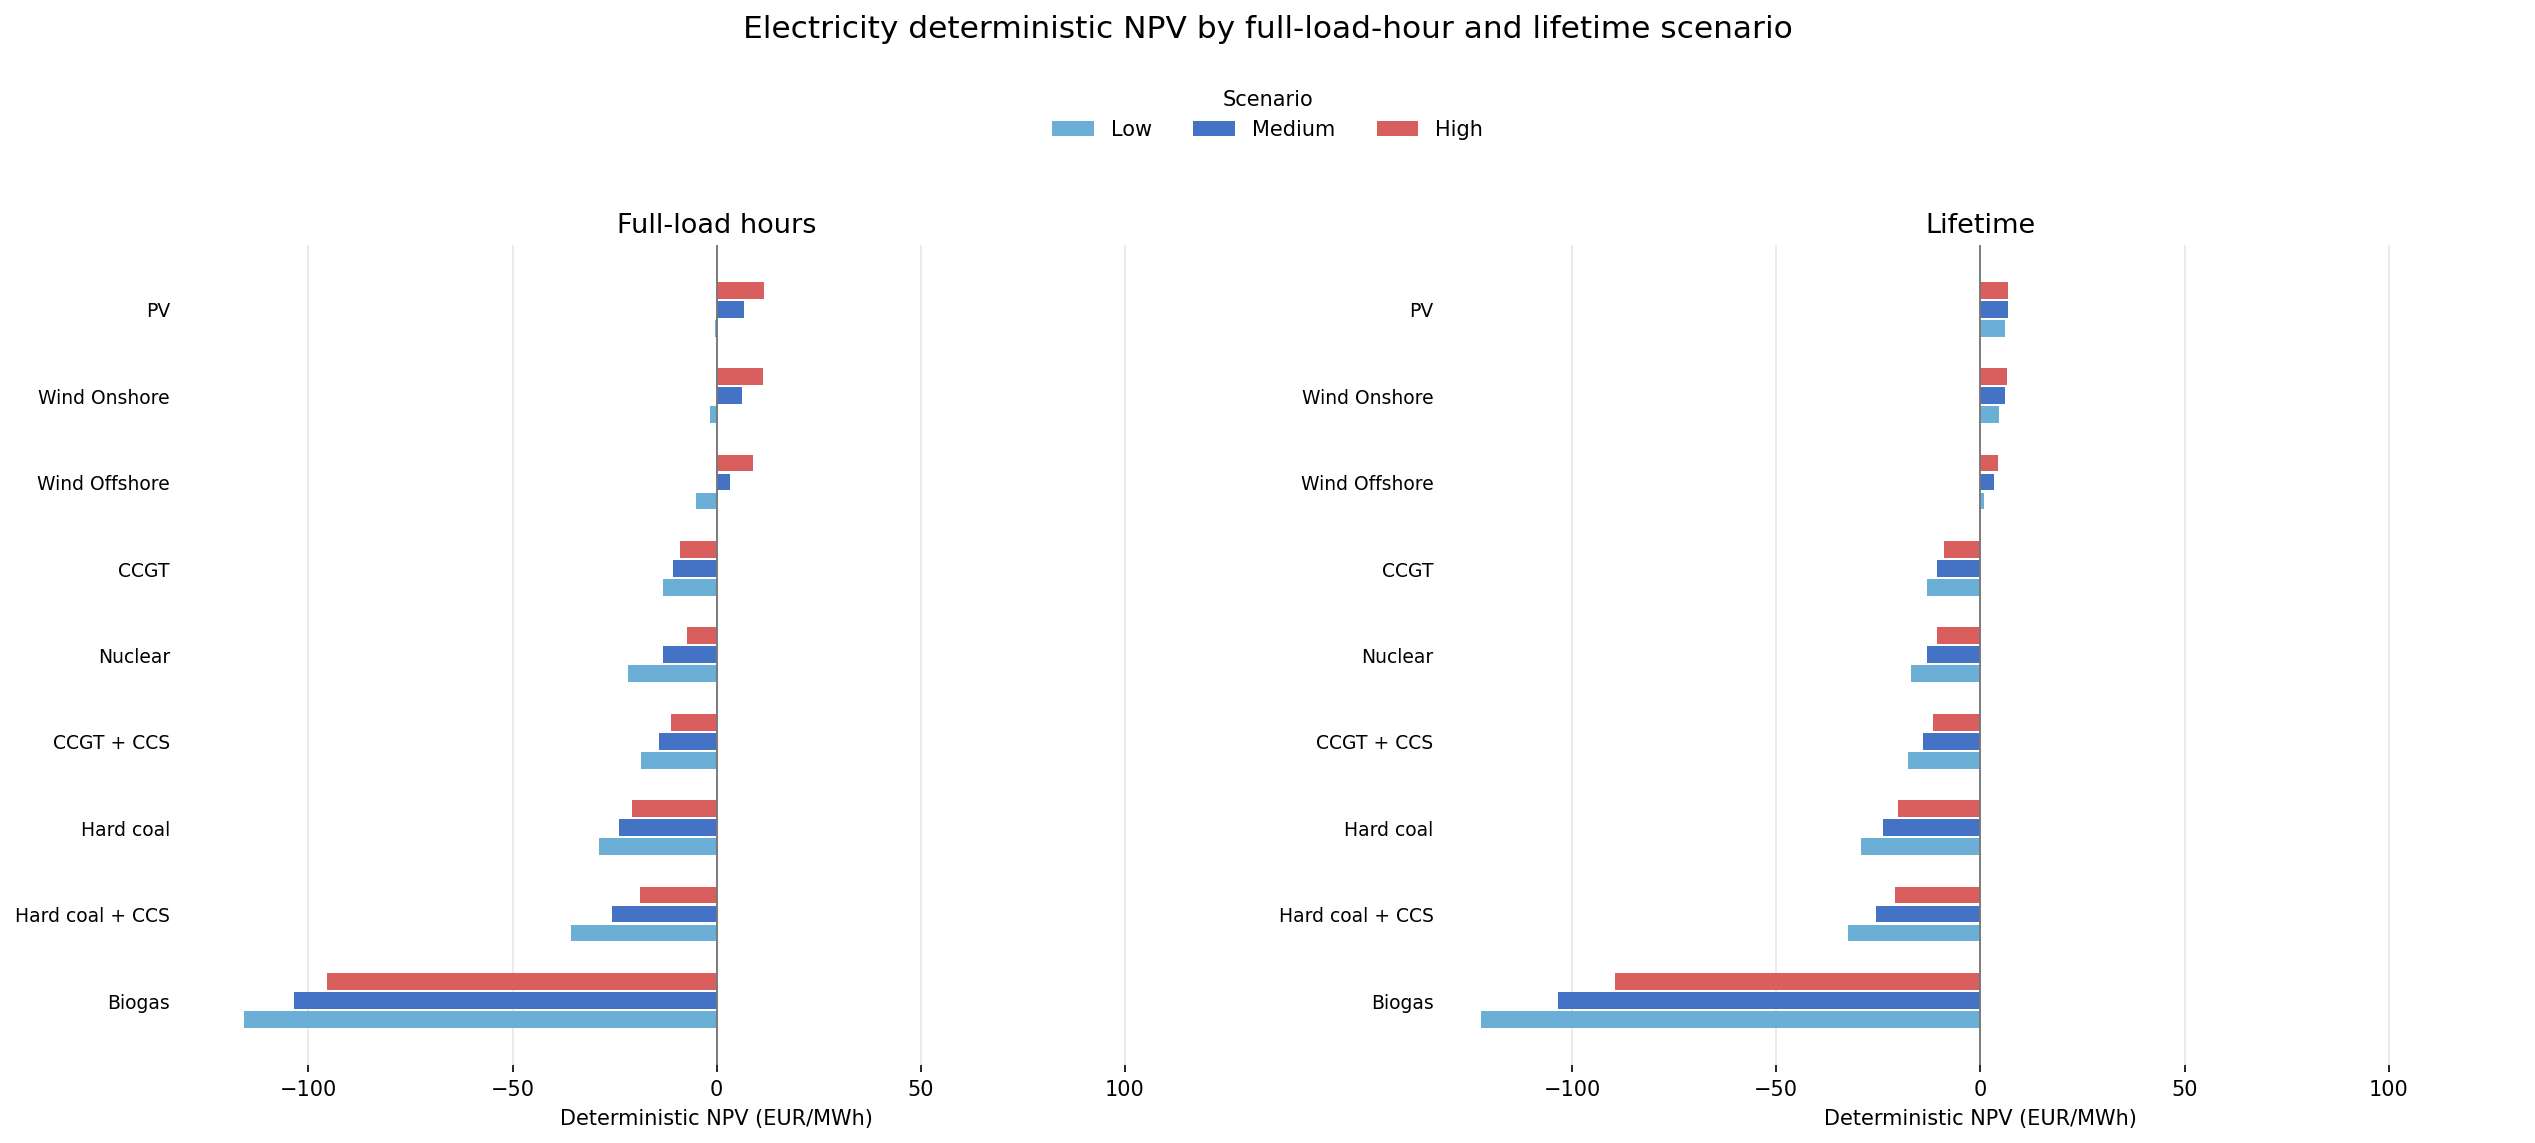

In [5]:
electricity_summary = pd.concat(
    [
        build_deterministic_scenario_summary(
            "electricity",
            electricity_base_inputs,
            ELECTRICITY_TECHNOLOGY_LABELS,
            "Full-load hours",
            "full_load_hours",
            ELECTRICITY_FLH_MULTIPLIERS,
            values_are_multipliers=True,
        ),
        build_deterministic_scenario_summary(
            "electricity",
            electricity_base_inputs,
            ELECTRICITY_TECHNOLOGY_LABELS,
            "Lifetime",
            "lifetime_years",
            ELECTRICITY_LIFETIME_MULTIPLIERS,
            values_are_multipliers=True,
        ),
    ],
    ignore_index=True,
)

display(electricity_summary)
plot_scenario_variables(
    electricity_summary,
    "Electricity deterministic NPV by full-load-hour and lifetime scenario",
    "electricity",
)
plt.show()


## Cement scenarios: CO2 price and discount rate

CO2 price and discount rate use explicit low / medium / high values. All other cement inputs remain fixed at their deterministic base values.


,sector,technology,label,scenario_variable,scenario,scenario_setting,base_value,applied_value,npv,delta_from_medium
0,Cement,bau,BAU,CO2 price,Low,40.000,80.000,40.000,29.218,10.248
1,Cement,bau,BAU,CO2 price,Medium,80.000,80.000,80.000,18.970,0.000
2,Cement,bau,BAU,CO2 price,High,120.000,80.000,120.000,8.723,-10.248
3,Cement,electrification,Electrification,CO2 price,Low,40.000,80.000,40.000,-36.689,6.832
4,Cement,electrification,Electrification,CO2 price,Medium,80.000,80.000,80.000,-43.521,0.000
5,Cement,electrification,Electrification,CO2 price,High,120.000,80.000,120.000,-50.353,-6.832
6,Cement,electrolysis,Electrolysis,CO2 price,Low,40.000,80.000,40.000,-159.100,1.708
7,Cement,electrolysis,Electrolysis,CO2 price,Medium,80.000,80.000,80.000,-160.808,0.000
8,Cement,electrolysis,Electrolysis,CO2 price,High,120.000,80.000,120.000,-162.516,-1.708
9,Cement,clinker_substitution,Clinker substitution,CO2 price,Low,40.000,80.000,40.000,29.089,8.967


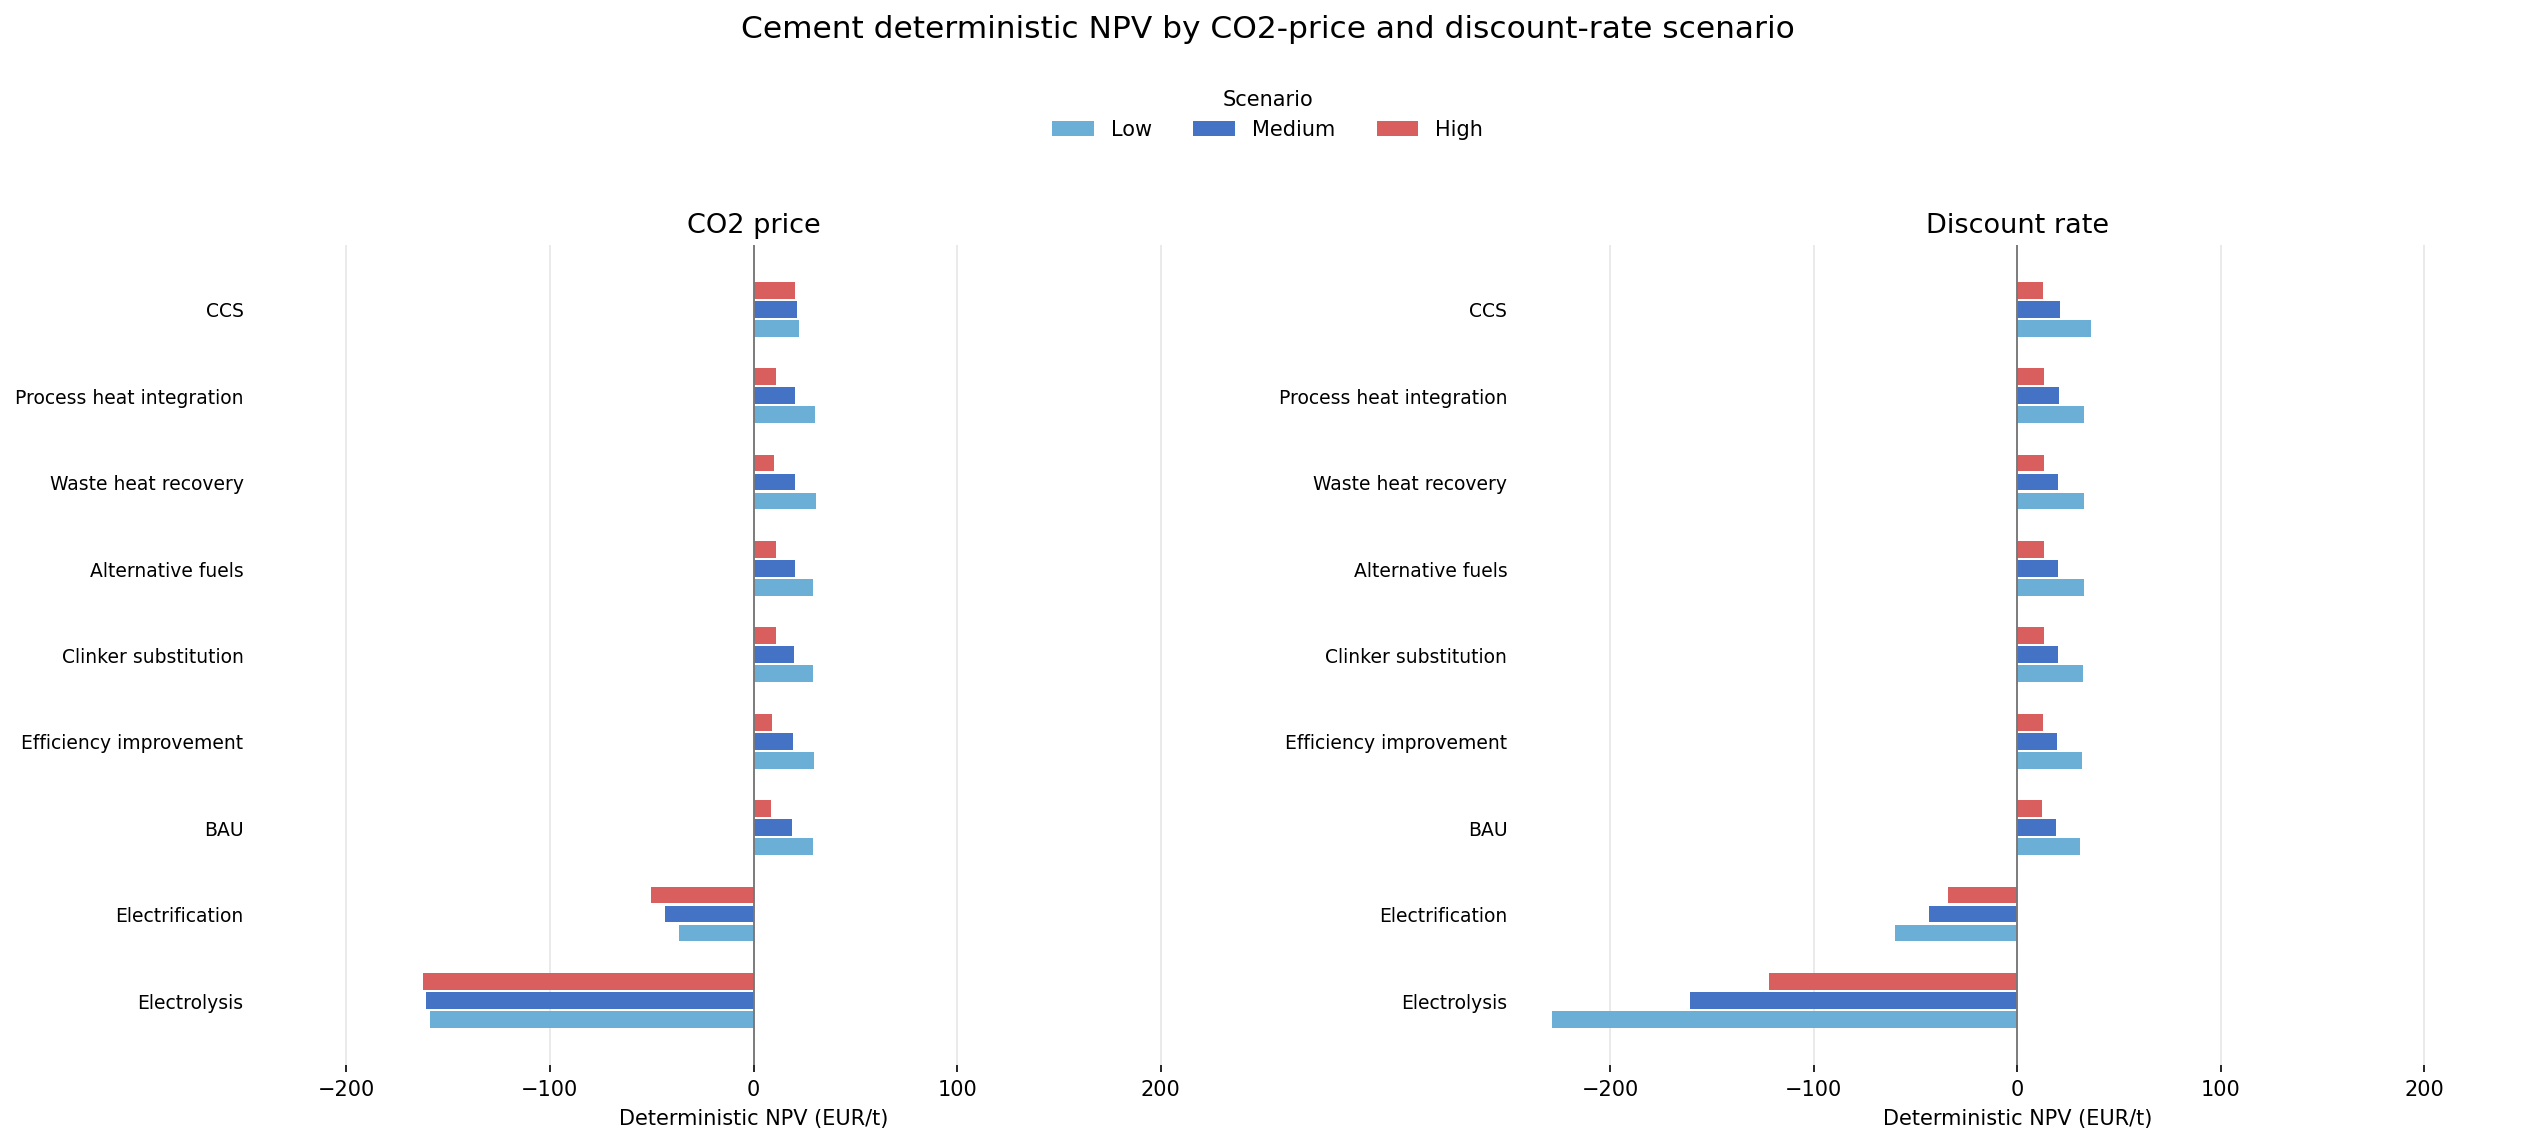

In [6]:
cement_summary = pd.concat(
    [
        build_deterministic_scenario_summary(
            "cement",
            cement_base_inputs,
            CEMENT_TECHNOLOGY_LABELS,
            "CO2 price",
            "carbon_price",
            CEMENT_CO2_PRICE_SCENARIOS,
        ),
        build_deterministic_scenario_summary(
            "cement",
            cement_base_inputs,
            CEMENT_TECHNOLOGY_LABELS,
            "Discount rate",
            "discount_rate",
            CEMENT_DISCOUNT_RATE_SCENARIOS,
        ),
    ],
    ignore_index=True,
)

display(cement_summary)
plot_scenario_variables(
    cement_summary,
    "Cement deterministic NPV by CO2-price and discount-rate scenario",
    "cement",
)
plt.show()


## Interpretation guardrails

- Low and high scenario values are sensitivity assumptions, not new thesis parameters.
- The medium cases come from the deterministic base assumptions in `src/`.
- Scenario comparisons are deterministic: no Monte Carlo simulations or sampled scenario cases are used.
- Electricity FLH and lifetime scenarios use relative multipliers because the deterministic base values differ by technology.
- Cement CO2-price and discount-rate scenarios use absolute editable values.
